In [ ]:
from google.colab import files
files.upload()

Saving data_banknote_authentication.csv to data_banknote_authentication.csv


{'data_banknote_authentication.csv': b'3.6216,8.6661,-2.8073,-0.44699,0\r\n4.5459,8.1674,-2.4586,-1.4621,0\r\n3.866,-2.6383,1.9242,0.10645,0\r\n3.4566,9.5228,-4.0112,-3.5944,0\r\n0.32924,-4.4552,4.5718,-0.9888,0\r\n4.3684,9.6718,-3.9606,-3.1625,0\r\n3.5912,3.0129,0.72888,0.56421,0\r\n2.0922,-6.81,8.4636,-0.60216,0\r\n3.2032,5.7588,-0.75345,-0.61251,0\r\n1.5356,9.1772,-2.2718,-0.73535,0\r\n1.2247,8.7779,-2.2135,-0.80647,0\r\n3.9899,-2.7066,2.3946,0.86291,0\r\n1.8993,7.6625,0.15394,-3.1108,0\r\n-1.5768,10.843,2.5462,-2.9362,0\r\n3.404,8.7261,-2.9915,-0.57242,0\r\n4.6765,-3.3895,3.4896,1.4771,0\r\n2.6719,3.0646,0.37158,0.58619,0\r\n0.80355,2.8473,4.3439,0.6017,0\r\n1.4479,-4.8794,8.3428,-2.1086,0\r\n5.2423,11.0272,-4.353,-4.1013,0\r\n5.7867,7.8902,-2.6196,-0.48708,0\r\n0.3292,-4.4552,4.5718,-0.9888,0\r\n3.9362,10.1622,-3.8235,-4.0172,0\r\n0.93584,8.8855,-1.6831,-1.6599,0\r\n4.4338,9.887,-4.6795,-3.7483,0\r\n0.7057,-5.4981,8.3368,-2.8715,0\r\n1.1432,-3.7413,5.5777,-0.63578,0\r\n-0.38214,8.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
sns.set_style("whitegrid")

COLS = ["variance", "skewness", "curtosis", "entropy", "class"]

df = pd.read_csv("data_banknote_authentication.csv", header=None, names=COLS)

print("\nFirst 5 samples:")
print(df.head())

print(f"\nDataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())

print("\nClass distribution:")
print(df["class"].value_counts())




First 5 samples:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset dimensions: 1372 rows, 5 columns

Missing values per column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Descriptive statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475 

Text(0.5, 1.02, 'Pairwise Feature Relationships by Banknote Class')

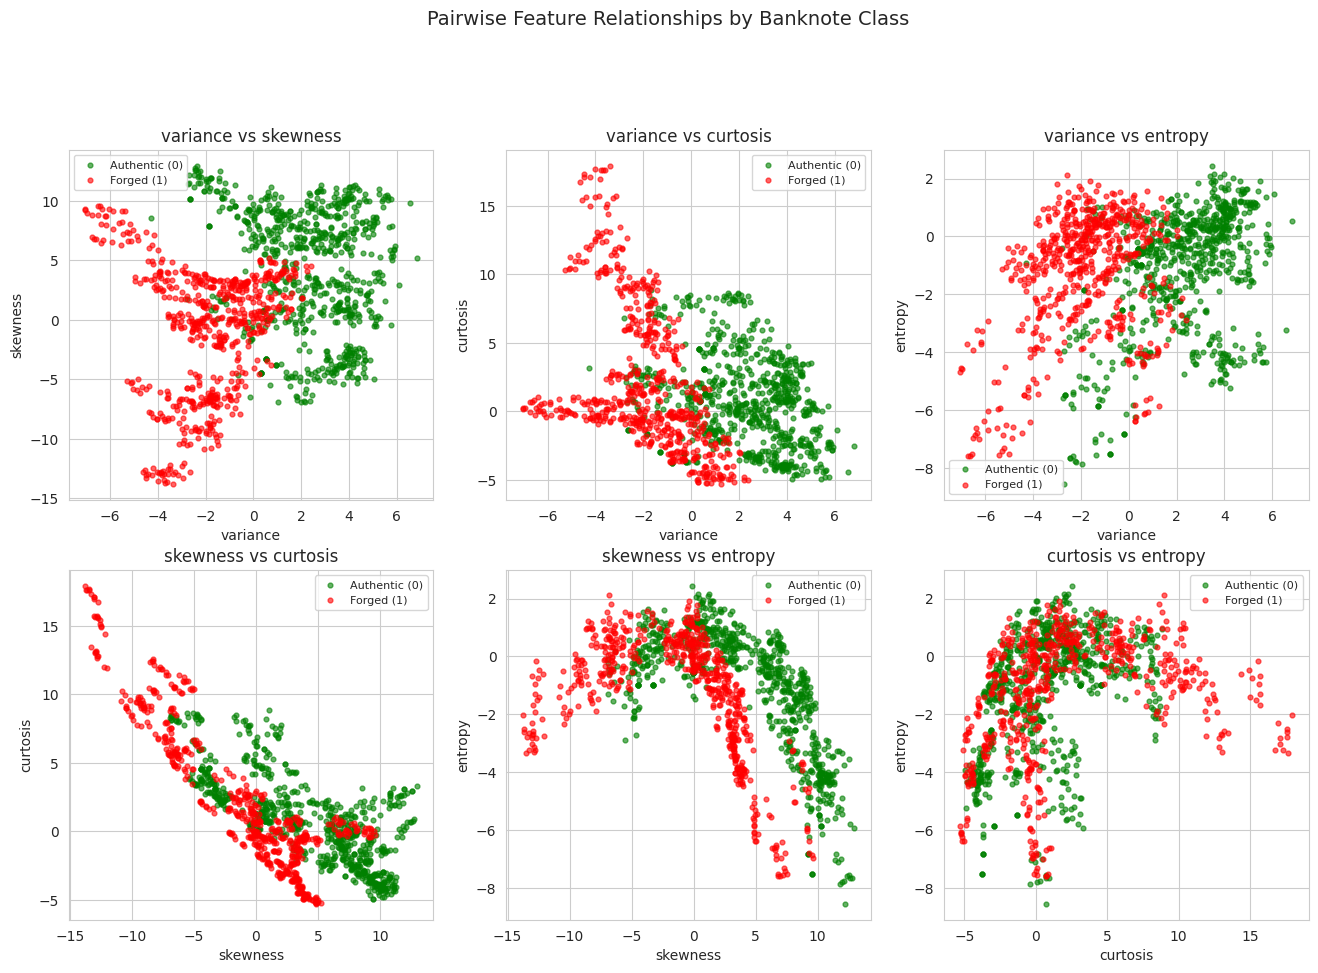

In [ ]:

# -------- Scatter Plots for All Feature Pairs --------
from itertools import combinations

features = ["variance", "skewness", "curtosis", "entropy"]
feature_pairs = list(combinations(features, 2))

# Combined figure containing all pairwise scatter plots
fig, subplot_axes = plt.subplots(2, 3, figsize=(16, 10))

for axis, (x_feature, y_feature) in zip(subplot_axes.ravel(), feature_pairs):

    authentic = df[df["class"] == 0]
    forged = df[df["class"] == 1]

    axis.scatter(
        authentic[x_feature],
        authentic[y_feature],
        color="green",
        s=12,
        alpha=0.6,
        label="Authentic (0)"
    )

    axis.scatter(
        forged[x_feature],
        forged[y_feature],
        color="red",
        s=12,
        alpha=0.6,
        label="Forged (1)"
    )

    axis.set_xlabel(x_feature)
    axis.set_ylabel(y_feature)
    axis.set_title(f"{x_feature} vs {y_feature}")
    axis.legend(fontsize=8)

plt.suptitle(
    "Pairwise Feature Relationships by Banknote Class",
    fontsize=14,
    y=1.02
)


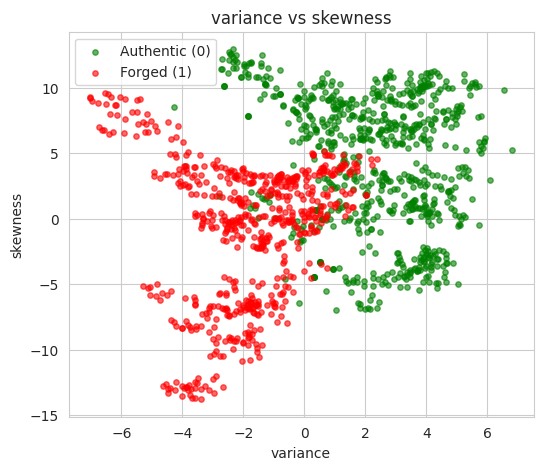

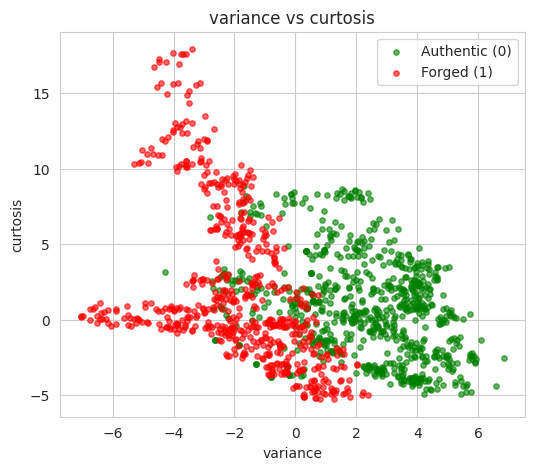

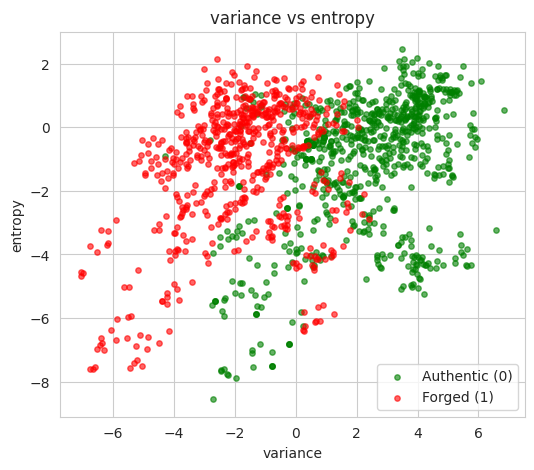

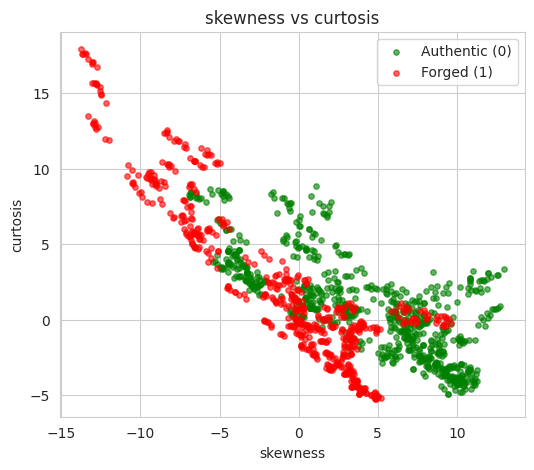

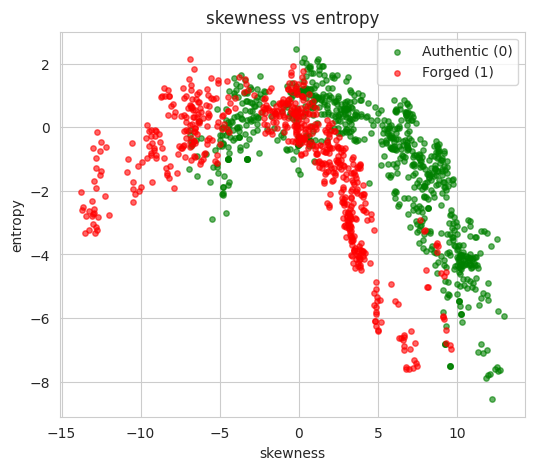

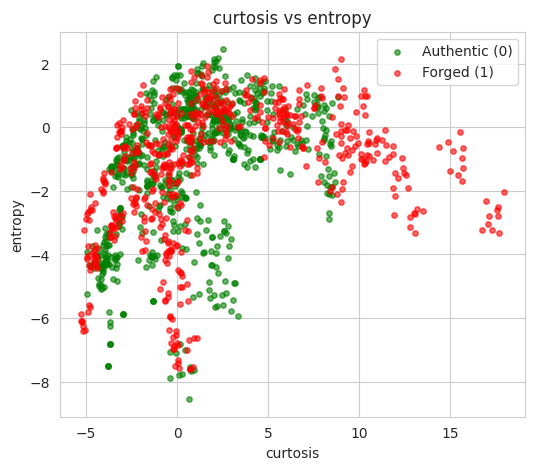

In [ ]:

# -------- Individual scatter plots --------
for x_feature, y_feature in feature_pairs:

    plt.figure(figsize=(6, 5))

    authentic = df[df["class"] == 0]
    forged = df[df["class"] == 1]

    plt.scatter(
        authentic[x_feature],
        authentic[y_feature],
        color="green",
        alpha=0.6,
        s=15,
        label="Authentic (0)"
    )

    plt.scatter(
        forged[x_feature],
        forged[y_feature],
        color="red",
        alpha=0.6,
        s=15,
        label="Forged (1)"
    )

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"{x_feature} vs {y_feature}")
    plt.legend()


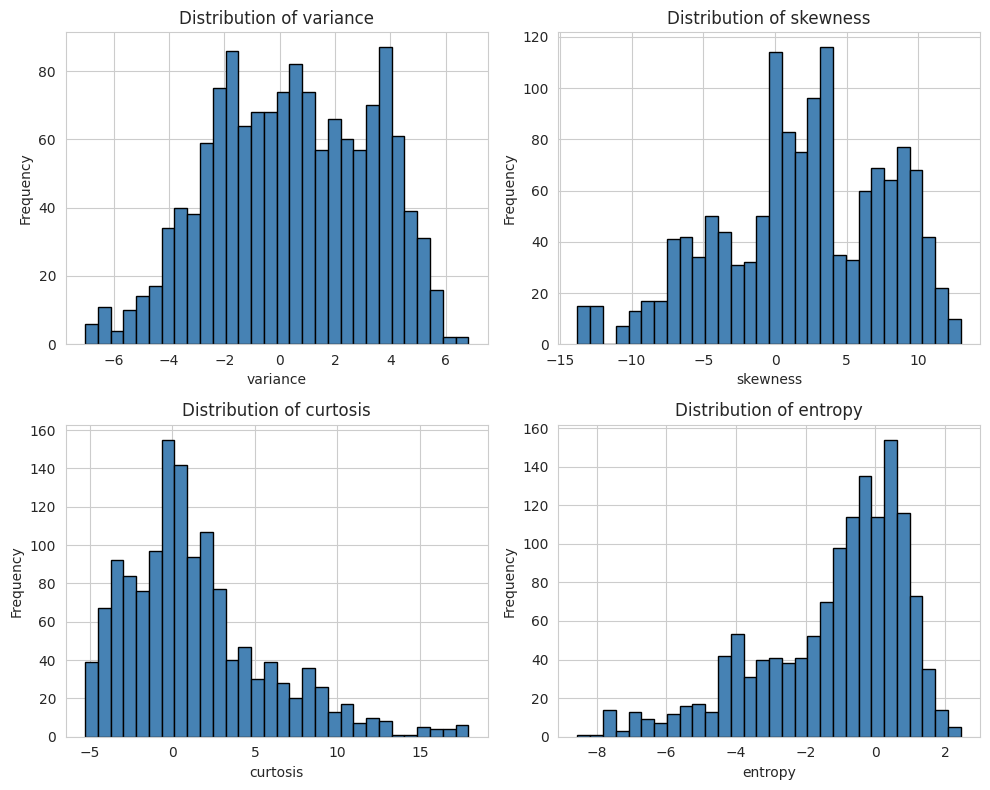

In [ ]:

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), COLS[:4]):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="black")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()


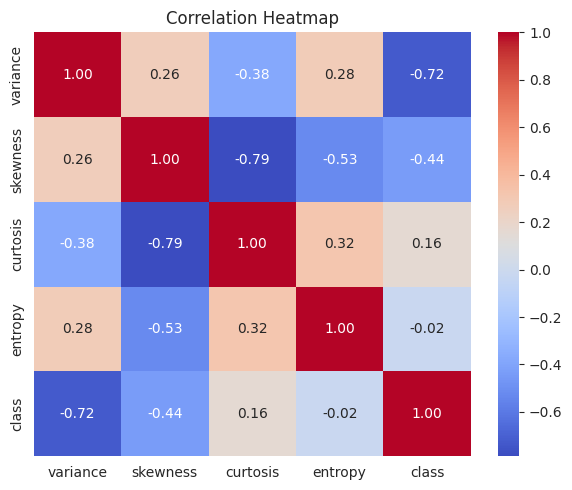

In [ ]:

# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()



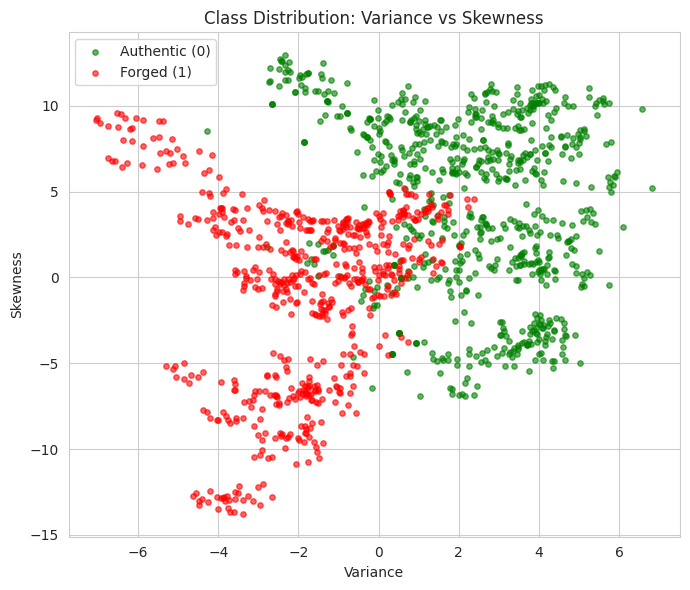

In [ ]:

#Scatter plot (two features: variance vs skewness)
plt.figure(figsize=(7, 6))
for cls, color, label in [(0, "green", "Authentic (0)"), (1, "red", "Forged (1)")]:
    subset = df[df["class"] == cls]
    plt.scatter(subset["variance"], subset["skewness"], c=color, alpha=0.6, label=label, s=15)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Class Distribution: Variance vs Skewness")
plt.legend()
plt.tight_layout()


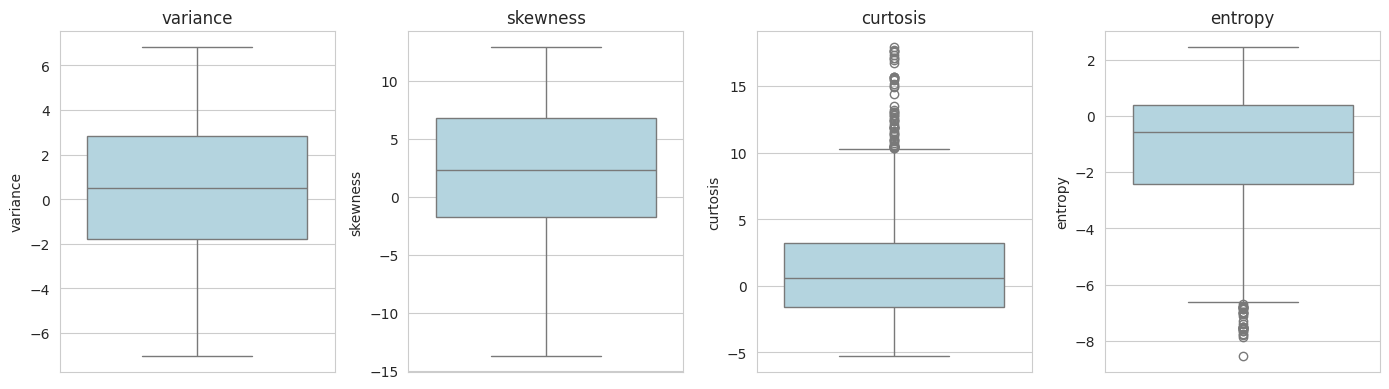

In [ ]:
# boxplots
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, COLS[:4]):
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(col)
plt.tight_layout()

In [ ]:
X = df[["variance", "skewness", "curtosis", "entropy"]].values
y = df["class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1097
Testing set size: 275


In [ ]:
import numpy as np

def step_activation(value):
    """Binary step activation function."""
    return np.where(value >= 0, 1, 0)


def predict(X, weights, bias):
    """Predict class labels."""

    linear_output = np.dot(X, weights) + bias
    return step_activation(linear_output)


def train_perceptron(X, y, learning_rate=0.01, n_epochs=50, random_state=42, verbose=True):

    random_gen = np.random.RandomState(random_state)

    weights = random_gen.normal(0, 0.01, X.shape[1])
    bias = 0.0

    history = {
        "epoch": [],
        "errors": [],
        "weights": [],
        "bias": []
    }

    for epoch in range(1, n_epochs + 1):

        errors = 0

        for features, target in zip(X, y):

            linear_output = np.dot(features, weights) + bias
            prediction = step_activation(linear_output)

            update = target - prediction

            if update != 0:

                weights += learning_rate * update * features
                bias += learning_rate * update

                errors += 1

        history["epoch"].append(epoch)
        history["errors"].append(errors)
        history["weights"].append(weights.copy())
        history["bias"].append(bias)

        if verbose and (epoch <= 5 or epoch % 10 == 0 or errors == 0):

            print(
                f"Epoch {epoch:3d} | "
                f"Misclassified: {errors:4d} | "
                f"Bias: {bias:.4f} | "
                f"Weights: {np.round(weights, 4)}"
            )

        if errors == 0:
            print(f"\nTraining converged after {epoch} epochs.")
            break

    return weights, bias, history


In [ ]:

LEARNING_RATE = 0.01
N_EPOCHS = 100

weights, bias, history = train_perceptron(
    X_train,
    y_train,
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS
)

y_pred = predict(X_test, weights, bias)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

Epoch   1 | Misclassified:   57 | Bias: -0.0300 | Weights: [-0.0623 -0.0697 -0.065  -0.0025]
Epoch   2 | Misclassified:   32 | Bias: -0.0500 | Weights: [-0.0851 -0.086  -0.0769  0.0013]
Epoch   3 | Misclassified:   31 | Bias: -0.0400 | Weights: [-0.1048 -0.1132 -0.0794  0.002 ]
Epoch   4 | Misclassified:   28 | Bias: -0.0600 | Weights: [-0.095  -0.1159 -0.1015  0.0081]
Epoch   5 | Misclassified:   26 | Bias: -0.0400 | Weights: [-0.1032 -0.1403 -0.1065  0.0074]
Epoch  10 | Misclassified:   23 | Bias: -0.0500 | Weights: [-0.1285 -0.1643 -0.134  -0.0084]
Epoch  20 | Misclassified:   16 | Bias: -0.0700 | Weights: [-0.1595 -0.1859 -0.161  -0.0176]
Epoch  30 | Misclassified:   13 | Bias: -0.0800 | Weights: [-0.1744 -0.1934 -0.1793 -0.0225]
Epoch  40 | Misclassified:   16 | Bias: -0.1000 | Weights: [-0.1916 -0.21   -0.2014 -0.0149]
Epoch  50 | Misclassified:   17 | Bias: -0.0900 | Weights: [-0.1927 -0.2256 -0.2151 -0.026 ]
Epoch  60 | Misclassified:   19 | Bias: -0.0900 | Weights: [-0.2034 -0

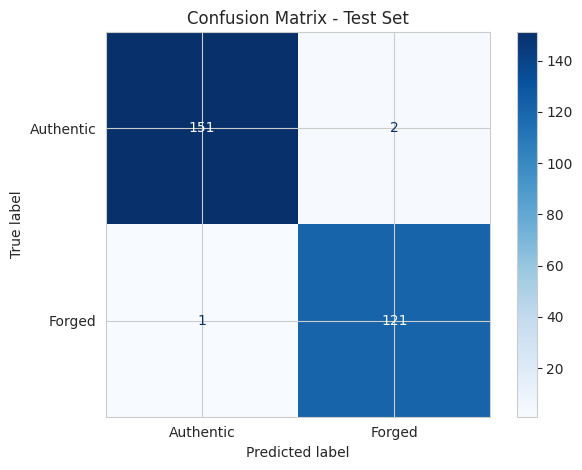

In [ ]:
# --- Confusion matrix plot ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic", "Forged"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()



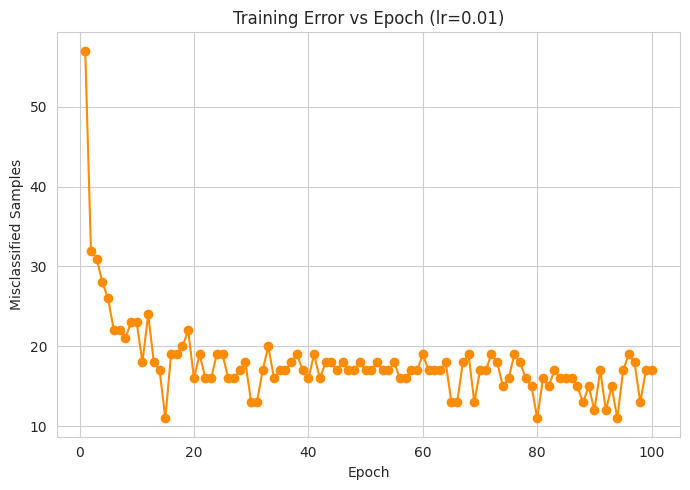

In [ ]:

# --- Training error vs epoch ---
plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["errors"], marker="o", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title(f"Training Error vs Epoch (lr={LEARNING_RATE})")
plt.tight_layout()



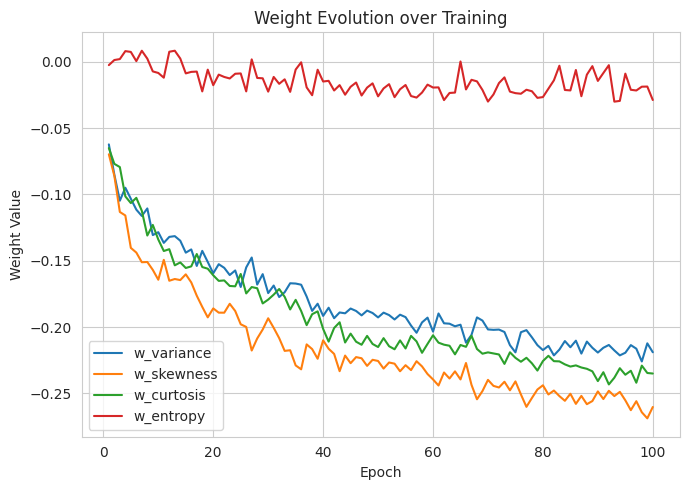

In [ ]:

# --- Weight evolution ---
weights_history = np.array(history["weights"])
plt.figure(figsize=(7, 5))
for i, col in enumerate(["variance", "skewness", "curtosis", "entropy"]):
    plt.plot(history["epoch"], weights_history[:, i], label=f"w_{col}")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution over Training")
plt.legend()
plt.tight_layout()


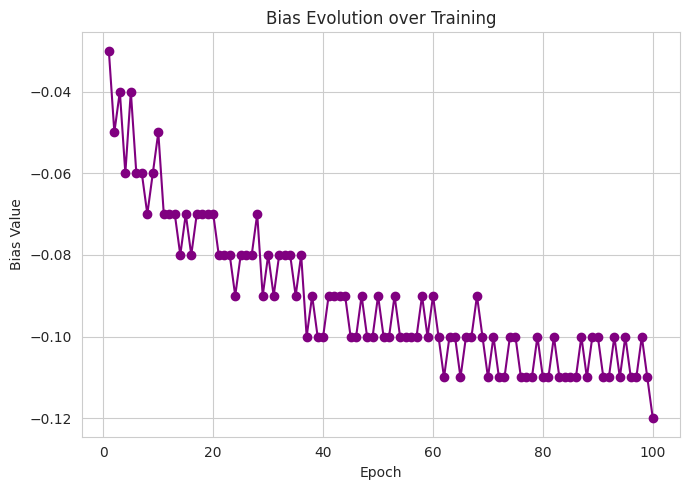

In [ ]:


# --- Bias evolution ---
plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["bias"], color="purple", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.title("Bias Evolution over Training")
plt.tight_layout()

learning_rates = [0.001, 0.01, 0.1]
lr_results = {}


lr=0.001  | epochs run: 100 | Test Accuracy: 0.9855
lr=0.01   | epochs run: 100 | Test Accuracy: 0.9891
lr=0.1    | epochs run: 100 | Test Accuracy: 0.9855


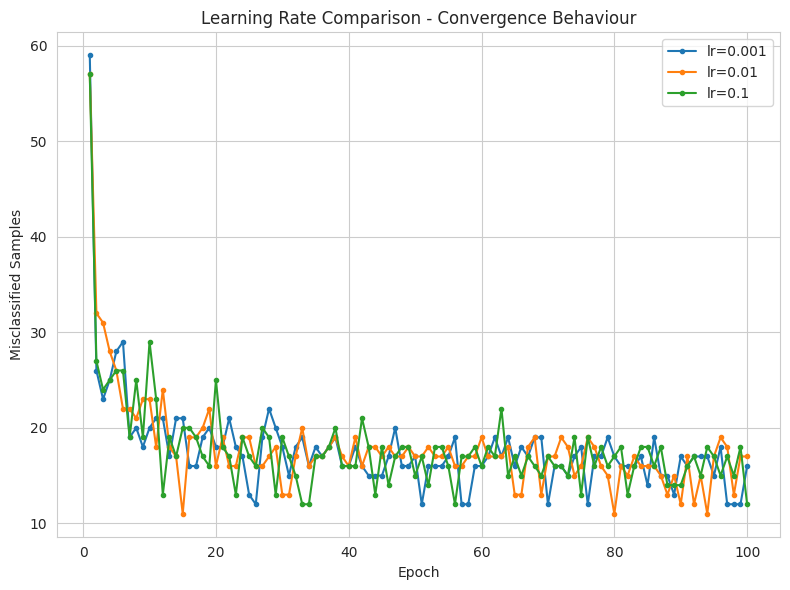

In [ ]:
plt.figure(figsize=(8, 6))

for lr in learning_rates:

    weights, bias, history = train_perceptron(
        X_train,
        y_train,
        learning_rate=lr,
        n_epochs=N_EPOCHS,
        verbose=False
    )

    lr_results[lr] = {
        "weights": weights,
        "bias": bias,
        "history": history
    }

    plt.plot(
        history["epoch"],
        history["errors"],
        marker=".",
        label=f"lr={lr}"
    )

    y_pred_lr = predict(X_test, weights, bias)

    print(
        f"lr={lr:<6} | "
        f"epochs run: {len(history['epoch']):3d} | "
        f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}"
    )

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison - Convergence Behaviour")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("TRAINING SUMMARY")
print("-" * 45)
summary = pd.DataFrame({
    "Metric": ["Dataset Size", "Train Size", "Test Size", "Learning Rate",
               "Epochs Run", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [len(df), len(X_train), len(X_test), LEARNING_RATE,
              len(history["epoch"]), round(bias, 4),
              round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]
})
print(summary.to_string(index=False))
summary.to_csv("training_summary.csv", index=False)

TRAINING SUMMARY
---------------------------------------------
       Metric     Value
 Dataset Size 1372.0000
   Train Size 1097.0000
    Test Size  275.0000
Learning Rate    0.0100
   Epochs Run  100.0000
   Final Bias   -1.1000
     Accuracy    0.9891
    Precision    0.9837
       Recall    0.9918
     F1-score    0.9878


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Train sklearn Perceptron
sk_model = Perceptron(
    max_iter=N_EPOCHS,
    eta0=LEARNING_RATE,
    random_state=42,
    tol=None
)

sk_model.fit(X_train, y_train)

# Predictions
y_pred_sk = sk_model.predict(X_test)

# Evaluation metrics
acc_sk = accuracy_score(y_test, y_pred_sk)
prec_sk = precision_score(y_test, y_pred_sk)
rec_sk = recall_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk)
cm_sk = confusion_matrix(y_test, y_pred_sk)

print("Scikit-learn Perceptron Results")
print("-" * 35)
print(f"Accuracy : {acc_sk:.4f}")
print(f"Precision: {prec_sk:.4f}")
print(f"Recall   : {rec_sk:.4f}")
print(f"F1-score : {f1_sk:.4f}")

print("\nConfusion Matrix:")
print(cm_sk)

Scikit-learn Perceptron Results
-----------------------------------
Accuracy : 0.9855
Precision: 0.9683
Recall   : 1.0000
F1-score : 0.9839

Confusion Matrix:
[[149   4]
 [  0 122]]


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Custom Perceptron": [acc, prec, rec, f1],
    "Sklearn Perceptron": [acc_sk, prec_sk, rec_sk, f1_sk]
})

comparison

,Metric,Custom Perceptron,Sklearn Perceptron
0,Accuracy,0.989091,0.985455
1,Precision,0.983740,0.968254
2,Recall,0.991803,1.000000
3,F1-score,0.987755,0.983871


In [ ]:
files.download("training_summary.csv")